In [1]:
import pandas as pd
from glob import glob
import numpy as np
from matplotlib.colors import ListedColormap

In [2]:
files = glob('../intermed_results/cervical/*.csv')

In [3]:
files = sorted(files)

In [4]:
files

['../intermed_results/cervical/adsgan_orig.csv',
 '../intermed_results/cervical/adsgan_prigen.csv',
 '../intermed_results/cervical/arf_orig.csv',
 '../intermed_results/cervical/arf_prigen.csv',
 '../intermed_results/cervical/ctgan_orig.csv',
 '../intermed_results/cervical/ctgan_prigen.csv',
 '../intermed_results/cervical/ddpm_orig.csv',
 '../intermed_results/cervical/ddpm_prigen.csv',
 '../intermed_results/cervical/decaf_orig.csv',
 '../intermed_results/cervical/decaf_prigen.csv',
 '../intermed_results/cervical/dpgan_orig.csv',
 '../intermed_results/cervical/dpgan_prigen.csv',
 '../intermed_results/cervical/dummy_sampler_orig.csv',
 '../intermed_results/cervical/dummy_sampler_prigen.csv',
 '../intermed_results/cervical/marginal_distributions_orig.csv',
 '../intermed_results/cervical/marginal_distributions_prigen.csv',
 '../intermed_results/cervical/nflow_orig.csv',
 '../intermed_results/cervical/nflow_prigen.csv',
 '../intermed_results/cervical/pategan_orig.csv',
 '../intermed_results/

In [5]:
synthesizers = list(set(['_'.join(file.split('/')[-1].split('.')[0].split('_')[:-1]) for file in files]))

In [6]:
synthesizers = [
    'adsgan',
    'pategan',
    'dpgan',
    'decaf',
    'nflow',
    'marginal_distributions',
    'uniform_sampler',
    'ctgan',
    'tvae',
    'dummy_sampler',
    'rtvae',
    'ddpm',
    'arf',
]

In [7]:
synthesizers = [
    'adsgan',
    'pategan',
    'dpgan',
    'decaf',
    'ctgan',
    'tvae',
    'rtvae',
    'ddpm',
    'arf',
]

In [8]:
def prepare_results(synth_name):
    paths = [file for file in files if f'/{synth_name}_' in file]
    df_list = []
    for path in paths:
        temp = pd.read_csv(path)
        temp = temp[['index', 'median', 'privgen_used']]
        temp.columns = ['metric', 'value', 'privgen_used']
        df_list.append(temp)
    df = pd.concat(df_list)
    df['synthesizer'] = synth_name
    df_pivot = df.pivot(index=['metric', 'synthesizer'], columns='privgen_used', values='value')
    try:
        # Rename columns for clarity
        df_pivot.columns = ['Orig', 'PrivGen']

        # Reset index to keep 'metric' and 'synthesizer'
        df_pivot.reset_index(inplace=True)
        df_pivot = df_pivot[~df_pivot['metric'].str.endswith('.gt')]
        return df_pivot
    except Exception as e:
        print(e)

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the metrics direction table
metrics_direction = pd.read_excel("../metrics_direction_2.xlsx")  
metrics_direction = metrics_direction.set_index("metric")  # Set metric as index for quick lookup

In [10]:
metrci_black_list = [
'privacy.identifiability_score.score', 
'privacy.identifiability_score.score_OC',
'stats.alpha_precision.authenticity_OC',
'stats.alpha_precision.delta_coverage_beta_OC',
'stats.alpha_precision.delta_precision_alpha_OC',
'stats.alpha_precision.delta_coverage_beta_naive',
'stats.alpha_precision.delta_precision_alpha_naive']

In [ ]:
label_map = {'privacy.delta-presence.score': ' Delta Presence',
             'privacy.distinct l-diversity.syn': 'l-diversity',
             'privacy.k-anonymization.syn': 'K-anonimization',
             'privacy.k-map.score': 'k-Map',
             'sanity.close_values_probability.score': 'Close Values Prob.',
             'sanity.common_rows_proportion.score': 'Common rows proportion',
             'sanity.data_mismatch.score': 'Data mismatch',
             'sanity.nearest_syn_neighbor_distance.mean': 'Nearest neighbor distance',
             'stats.alpha_precision.authenticity_naive': 'Alpha precision authenticity', 
             'stats.chi_squared_test.marginal': 'Chi-squared',
             'stats.inv_kl_divergence.marginal': 'KL-divergence',
             'stats.jensenshannon_dist.marginal': 'Jensen-Shannon distance',
             'stats.ks_test.marginal': 'KS test',
             'stats.max_mean_discrepancy.joint': 'Max Mean discrepancy',
             'stats.prdc.coverage': 'PRDC coverage',
             'stats.prdc.density': 'PRDC density',
             'stats.prdc.precision': 'PRDC precision',
             'stats.prdc.recall': 'PRDC recall',
             'stats.wasserstein_dist.joint': 'Wasserstein distance'}

In [47]:
# List of synthesizer result files (replace with actual file names)
# synthesizer_files = [prepare_results(synth) for synth in synthesizers]

# Initialize an empty dictionary to store results
comparison_results = {}

for synth in synthesizers:
    # Load synthesizer table
    df = prepare_results(synth)

    # Extract synthesizer name from file (assuming filename format is "synth_name.csv")
    synthesizer_name = df['synthesizer'][0]

    # Initialize results storage
    comparison_results[synthesizer_name] = {}

    for _, row in df.iterrows():
        metric = row["metric"]
        # print(metric)
        if metric not in metrci_black_list:
            orig_value = row["Orig"]
            privgen_value = row["PrivGen"]

            # Get direction from metrics_direction table
            if metric in metrics_direction.index:
                direction = metrics_direction.loc[metric, "Direction"]

                # Compare values based on direction
                if direction == "Min":
                    improved = 1 if privgen_value < orig_value else 0
                elif direction == "Max":
                    improved = 1 if privgen_value > orig_value else 0
                else:
                    improved = 0  # Default to 0 if direction is unclear

                comparison_results[synthesizer_name][metric] = improved

# Convert to DataFrame
comparison_df = pd.DataFrame(comparison_results).fillna(
    0)  # Fill missing values with 0


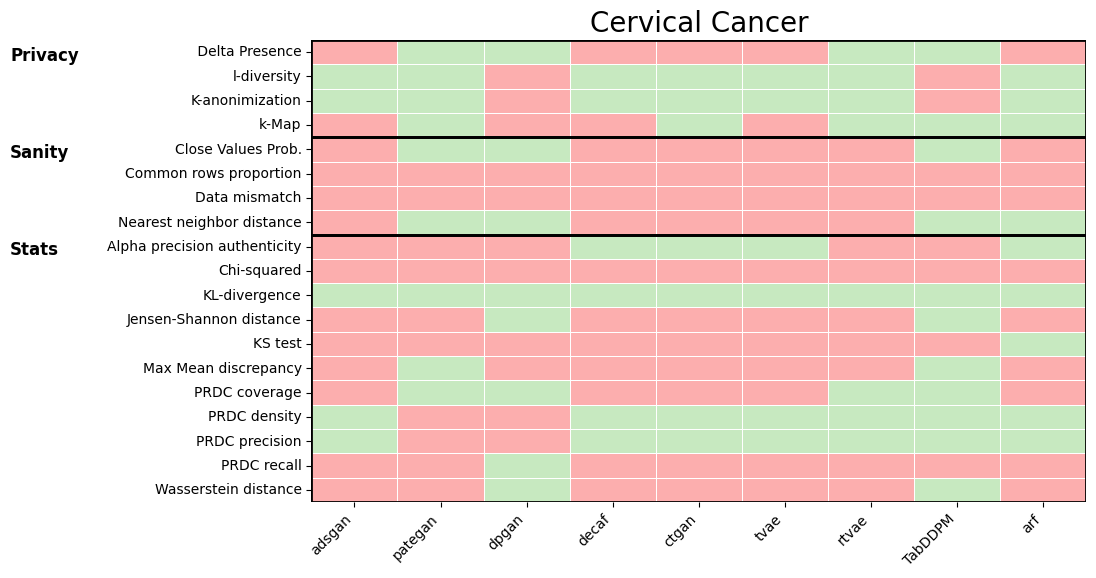

In [48]:
grouped_metrics = {}
for metric in comparison_df.index:
    category = metric.split('.')[0]  # e.g., 'privacy', 'sanity', 'stats'
    if category not in grouped_metrics:
        grouped_metrics[category] = []
    grouped_metrics[category].append(metric)

# Build a new index that groups metrics by category
new_index = []
for category, metrics_in_cat in grouped_metrics.items():
    new_index.extend(metrics_in_cat)

# Reindex the DataFrame to group metrics by category
comparison_df = comparison_df.loc[new_index]

# Create y-axis labels from your label_map
y_labels = [label_map.get(m, m) for m in comparison_df.index]

# -------------------------------------------------------------------
# 2) CREATE A LESS-BRIGHT (PASTEL) COLORMAP
#    (-1 => Red, 0 => White, 1 => Green in your logic)
# -------------------------------------------------------------------
not_improved_color = "#fcaeae"  # pastel red
unchanged_color    = "#f7f7f7"  # near white
improved_color     = "#c7e9c0"  # pastel green
custom_cmap = ListedColormap([not_improved_color, unchanged_color, improved_color])

comparison_array = comparison_df.to_numpy()
# Map (-1 => 0), (0 => 1), (1 => 2) for the colormap index
comparison_mapped = np.where(comparison_array == 1, 2, 
                     np.where(comparison_array == 0, 1, 0))

# -------------------------------------------------------------------
# 3) PLOT THE HEATMAP
# -------------------------------------------------------------------
plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    comparison_mapped,
    cmap=custom_cmap,
    annot=False,
    linewidths=0.5,
    cbar=False,
    xticklabels=comparison_df.columns,
    yticklabels=y_labels
)

plt.title('Cervical Cancer', fontsize=20)
# plt.title("Improvement of PrivGen Over Original (Green=Improved, White=Unchanged, Red=Not Improved)")

# Replace 'ddpm' with 'TabDDPM' if needed
xtick_labels = ['TabDDPM' if label == 'ddpm' else label for label in comparison_df.columns]
plt.xticks(
    ticks=[i + 0.5 for i in range(len(comparison_df.columns))],
    labels=xtick_labels,
    rotation=45,
    ha='right'
)
plt.yticks(rotation=0)

# -------------------------------------------------------------------
# 4) DRAW BOXES AROUND EACH CATEGORY
#    (Remove or comment out any hline code you used before.)
# -------------------------------------------------------------------
n_cols = comparison_df.shape[1]
x_start = 0    # left edge of the heatmap cells
x_end   = n_cols  # right edge (number of columns)

current_row = 0
for category, metrics_in_cat in grouped_metrics.items():
    cat_size = len(metrics_in_cat)
    # y-coordinates for this category's box
    y_start = current_row
    y_end   = current_row + cat_size

    # Draw a rectangle around the group
    # Note: Heatmap cells go from (row, col) in integer steps.
    # For a perfect box, offset by -0.5 so lines are on grid boundaries.
    rect = plt.Rectangle(
        (x_start - 0, y_start - 0),   # bottom-left corner
        x_end,                            # width
        cat_size,                         # height
        fill=False,
        edgecolor='black',
        linewidth=2
    )
    ax.add_patch(rect)

    # Place the category label at the top-left corner of the box
    # Adjust x/y offsets and alignment to your preference
    ax.text(
        x_start - 3.5,                   # a bit left of the box
        y_start + 1,                     # near the top of the box
        category.capitalize(),
        va='bottom',                     # anchor text at bottom
        ha='left',
        fontsize=12,
        fontweight='bold'
    )

    current_row = y_end

plt.show()

Private models:
- AdsGAN
- PATEGAN
- DP-GAN
- DECAF

In [49]:
files = glob('../intermed_results/health/*.csv')

In [50]:
files = sorted(files)

In [51]:
# List of synthesizer result files (replace with actual file names)
# synthesizer_files = [prepare_results(synth) for synth in synthesizers]

# Initialize an empty dictionary to store results
comparison_results = {}

for synth in synthesizers:
    # Load synthesizer table
    df = prepare_results(synth)

    # Extract synthesizer name from file (assuming filename format is "synth_name.csv")
    synthesizer_name = df['synthesizer'][0]

    # Initialize results storage
    comparison_results[synthesizer_name] = {}

    for _, row in df.iterrows():
        metric = row["metric"]
        # print(metric)
        if metric not in metrci_black_list:
            orig_value = row["Orig"]
            privgen_value = row["PrivGen"]

            # Get direction from metrics_direction table
            if metric in metrics_direction.index:
                direction = metrics_direction.loc[metric, "Direction"]

                # Compare values based on direction
                if direction == "Min":
                    improved = 1 if privgen_value < orig_value else 0
                elif direction == "Max":
                    improved = 1 if privgen_value > orig_value else 0
                else:
                    improved = 0  # Default to 0 if direction is unclear

                comparison_results[synthesizer_name][metric] = improved

# Convert to DataFrame
comparison_df = pd.DataFrame(comparison_results).fillna(
    0)  # Fill missing values with 0


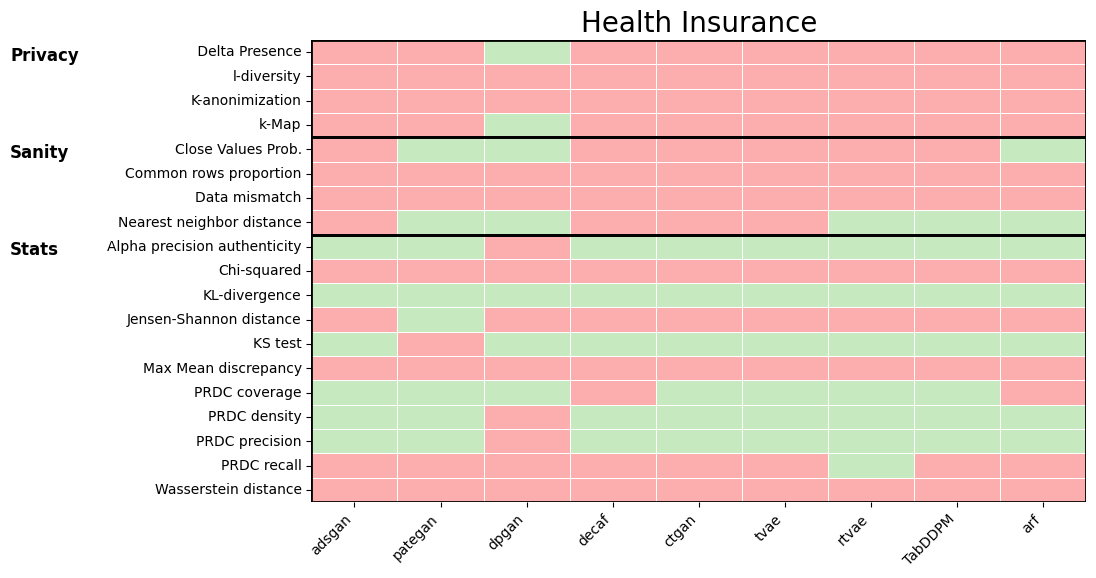

In [52]:
grouped_metrics = {}
for metric in comparison_df.index:
    category = metric.split('.')[0]  # e.g., 'privacy', 'sanity', 'stats'
    if category not in grouped_metrics:
        grouped_metrics[category] = []
    grouped_metrics[category].append(metric)

# Build a new index that groups metrics by category
new_index = []
for category, metrics_in_cat in grouped_metrics.items():
    new_index.extend(metrics_in_cat)

# Reindex the DataFrame to group metrics by category
comparison_df = comparison_df.loc[new_index]

# Create y-axis labels from your label_map
y_labels = [label_map.get(m, m) for m in comparison_df.index]

# -------------------------------------------------------------------
# 2) CREATE A LESS-BRIGHT (PASTEL) COLORMAP
#    (-1 => Red, 0 => White, 1 => Green in your logic)
# -------------------------------------------------------------------
not_improved_color = "#fcaeae"  # pastel red
unchanged_color    = "#f7f7f7"  # near white
improved_color     = "#c7e9c0"  # pastel green
custom_cmap = ListedColormap([not_improved_color, unchanged_color, improved_color])

comparison_array = comparison_df.to_numpy()
# Map (-1 => 0), (0 => 1), (1 => 2) for the colormap index
comparison_mapped = np.where(comparison_array == 1, 2, 
                     np.where(comparison_array == 0, 1, 0))

# -------------------------------------------------------------------
# 3) PLOT THE HEATMAP
# -------------------------------------------------------------------
plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    comparison_mapped,
    cmap=custom_cmap,
    annot=False,
    linewidths=0.5,
    cbar=False,
    xticklabels=comparison_df.columns,
    yticklabels=y_labels
)

plt.title('Health Insurance', fontsize=20)
# plt.title("Improvement of PrivGen Over Original (Green=Improved, White=Unchanged, Red=Not Improved)")

# Replace 'ddpm' with 'TabDDPM' if needed
xtick_labels = ['TabDDPM' if label == 'ddpm' else label for label in comparison_df.columns]
plt.xticks(
    ticks=[i + 0.5 for i in range(len(comparison_df.columns))],
    labels=xtick_labels,
    rotation=45,
    ha='right'
)
plt.yticks(rotation=0)

# -------------------------------------------------------------------
# 4) DRAW BOXES AROUND EACH CATEGORY
#    (Remove or comment out any hline code you used before.)
# -------------------------------------------------------------------
n_cols = comparison_df.shape[1]
x_start = 0    # left edge of the heatmap cells
x_end   = n_cols  # right edge (number of columns)

current_row = 0
for category, metrics_in_cat in grouped_metrics.items():
    cat_size = len(metrics_in_cat)
    # y-coordinates for this category's box
    y_start = current_row
    y_end   = current_row + cat_size

    # Draw a rectangle around the group
    # Note: Heatmap cells go from (row, col) in integer steps.
    # For a perfect box, offset by -0.5 so lines are on grid boundaries.
    rect = plt.Rectangle(
        (x_start - 0, y_start - 0),   # bottom-left corner
        x_end,                            # width
        cat_size,                         # height
        fill=False,
        edgecolor='black',
        linewidth=2
    )
    ax.add_patch(rect)

    # Place the category label at the top-left corner of the box
    # Adjust x/y offsets and alignment to your preference
    ax.text(
        x_start - 3.5,                   # a bit left of the box
        y_start + 1,                     # near the top of the box
        category.capitalize(),
        va='bottom',                     # anchor text at bottom
        ha='left',
        fontsize=12,
        fontweight='bold'
    )

    current_row = y_end

plt.show()

In [53]:
files = glob('../intermed_results/german/*.csv')

In [54]:
files = sorted(files)

In [56]:
# List of synthesizer result files (replace with actual file names)
# synthesizer_files = [prepare_results(synth) for synth in synthesizers]

# Initialize an empty dictionary to store results
comparison_results = {}

for synth in synthesizers:
    # Load synthesizer table
    df = prepare_results(synth)

    # Extract synthesizer name from file (assuming filename format is "synth_name.csv")
    synthesizer_name = df['synthesizer'][0]

    # Initialize results storage
    comparison_results[synthesizer_name] = {}

    for _, row in df.iterrows():
        metric = row["metric"]
        # print(metric)
        if metric not in metrci_black_list:
            orig_value = row["Orig"]
            privgen_value = row["PrivGen"]

            # Get direction from metrics_direction table
            if metric in metrics_direction.index:
                direction = metrics_direction.loc[metric, "Direction"]

                # Compare values based on direction
                if direction == "Min":
                    improved = 1 if privgen_value < orig_value else 0
                elif direction == "Max":
                    improved = 1 if privgen_value > orig_value else 0
                else:
                    improved = 0  # Default to 0 if direction is unclear

                comparison_results[synthesizer_name][metric] = improved

# Convert to DataFrame
comparison_df = pd.DataFrame(comparison_results).fillna(
    0)  # Fill missing values with 0


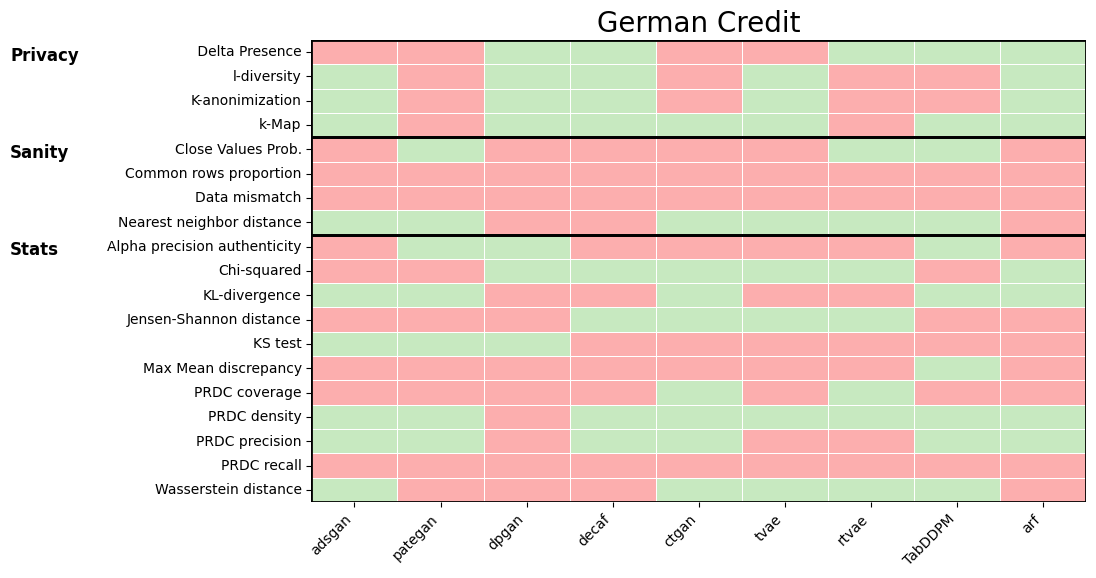

In [57]:
grouped_metrics = {}
for metric in comparison_df.index:
    category = metric.split('.')[0]  # e.g., 'privacy', 'sanity', 'stats'
    if category not in grouped_metrics:
        grouped_metrics[category] = []
    grouped_metrics[category].append(metric)

# Build a new index that groups metrics by category
new_index = []
for category, metrics_in_cat in grouped_metrics.items():
    new_index.extend(metrics_in_cat)

# Reindex the DataFrame to group metrics by category
comparison_df = comparison_df.loc[new_index]

# Create y-axis labels from your label_map
y_labels = [label_map.get(m, m) for m in comparison_df.index]

# -------------------------------------------------------------------
# 2) CREATE A LESS-BRIGHT (PASTEL) COLORMAP
#    (-1 => Red, 0 => White, 1 => Green in your logic)
# -------------------------------------------------------------------
not_improved_color = "#fcaeae"  # pastel red
unchanged_color    = "#f7f7f7"  # near white
improved_color     = "#c7e9c0"  # pastel green
custom_cmap = ListedColormap([not_improved_color, unchanged_color, improved_color])

comparison_array = comparison_df.to_numpy()
# Map (-1 => 0), (0 => 1), (1 => 2) for the colormap index
comparison_mapped = np.where(comparison_array == 1, 2, 
                     np.where(comparison_array == 0, 1, 0))

# -------------------------------------------------------------------
# 3) PLOT THE HEATMAP
# -------------------------------------------------------------------
plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    comparison_mapped,
    cmap=custom_cmap,
    annot=False,
    linewidths=0.5,
    cbar=False,
    xticklabels=comparison_df.columns,
    yticklabels=y_labels
)

plt.title('German Credit', fontsize=20)
# plt.title("Improvement of PrivGen Over Original (Green=Improved, White=Unchanged, Red=Not Improved)")

# Replace 'ddpm' with 'TabDDPM' if needed
xtick_labels = ['TabDDPM' if label == 'ddpm' else label for label in comparison_df.columns]
plt.xticks(
    ticks=[i + 0.5 for i in range(len(comparison_df.columns))],
    labels=xtick_labels,
    rotation=45,
    ha='right'
)
plt.yticks(rotation=0)

# -------------------------------------------------------------------
# 4) DRAW BOXES AROUND EACH CATEGORY
#    (Remove or comment out any hline code you used before.)
# -------------------------------------------------------------------
n_cols = comparison_df.shape[1]
x_start = 0    # left edge of the heatmap cells
x_end   = n_cols  # right edge (number of columns)

current_row = 0
for category, metrics_in_cat in grouped_metrics.items():
    cat_size = len(metrics_in_cat)
    # y-coordinates for this category's box
    y_start = current_row
    y_end   = current_row + cat_size

    # Draw a rectangle around the group
    # Note: Heatmap cells go from (row, col) in integer steps.
    # For a perfect box, offset by -0.5 so lines are on grid boundaries.
    rect = plt.Rectangle(
        (x_start - 0, y_start - 0),   # bottom-left corner
        x_end,                            # width
        cat_size,                         # height
        fill=False,
        edgecolor='black',
        linewidth=2
    )
    ax.add_patch(rect)

    # Place the category label at the top-left corner of the box
    # Adjust x/y offsets and alignment to your preference
    ax.text(
        x_start - 3.5,                   # a bit left of the box
        y_start + 1,                     # near the top of the box
        category.capitalize(),
        va='bottom',                     # anchor text at bottom
        ha='left',
        fontsize=12,
        fontweight='bold'
    )

    current_row = y_end

plt.show()